In [1]:
pip install packages

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement packages (from versions: none)
ERROR: No matching distribution found for packages


In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("ER Wait Time Dataset.csv")

df.head()

,Visit ID,Patient ID,Hospital ID,Hospital Name,Region,Visit Date,Day of Week,Season,Time of Day,Urgency Level,Nurse-to-Patient Ratio,Specialist Availability,Facility Size (Beds),Time to Registration (min),Time to Triage (min),Time to Medical Professional (min),Total Wait Time (min),Patient Outcome,Patient Satisfaction
0,HOSP-1-20240210-0001,PAT-00001,HOSP-1,Springfield General Hospital,Urban,2024-02-10 20:20:56,Saturday,Winter,Late Morning,Medium,4,3,92,17,22,66,105,Discharged,1
1,HOSP-3-20241128-0001,PAT-00002,HOSP-3,Northside Community Hospital,Rural,2024-11-28 02:07:47,Thursday,Fall,Evening,Medium,4,0,38,9,30,30,69,Discharged,3
2,HOSP-3-20240930-0002,PAT-00003,HOSP-3,Northside Community Hospital,Rural,2024-09-30 04:02:28,Monday,Fall,Evening,Low,5,1,38,38,40,125,203,Discharged,1
3,HOSP-2-20240227-0001,PAT-00004,HOSP-2,Riverside Medical Center,Urban,2024-02-27 00:31:13,Tuesday,Winter,Evening,High,4,5,94,8,16,64,88,Discharged,2
4,HOSP-1-20240306-0002,PAT-00005,HOSP-1,Springfield General Hospital,Urban,2024-03-06 16:52:26,Wednesday,Spring,Afternoon,Low,4,8,74,26,29,63,118,Discharged,1


In [4]:
print(df.shape)

print(df.columns)

df.info()

df.describe(include='all')

(5000, 19)
Index(['Visit ID', 'Patient ID', 'Hospital ID', 'Hospital Name', 'Region',
       'Visit Date', 'Day of Week', 'Season', 'Time of Day', 'Urgency Level',
       'Nurse-to-Patient Ratio', 'Specialist Availability',
       'Facility Size (Beds)', 'Time to Registration (min)',
       'Time to Triage (min)', 'Time to Medical Professional (min)',
       'Total Wait Time (min)', 'Patient Outcome', 'Patient Satisfaction'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Visit ID                            5000 non-null   object
 1   Patient ID                          5000 non-null   object
 2   Hospital ID                         5000 non-null   object
 3   Hospital Name                       5000 non-null   object
 4   Region                              5000 non-null   

,Visit ID,Patient ID,Hospital ID,Hospital Name,Region,Visit Date,Day of Week,Season,Time of Day,Urgency Level,Nurse-to-Patient Ratio,Specialist Availability,Facility Size (Beds),Time to Registration (min),Time to Triage (min),Time to Medical Professional (min),Total Wait Time (min),Patient Outcome,Patient Satisfaction
count,5000,5000,5000,5000,5000,5000,5000,5000,5000,5000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000,5000.000000
unique,5000,5000,5,5,2,5000,7,4,5,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN
top,HOSP-1-20240210-0001,PAT-00001,HOSP-2,Riverside Medical Center,Urban,2024-02-10 20:20:56,Monday,Summer,Evening,Medium,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Discharged,NaN
freq,1,1,1023,1023,3006,1,768,1281,1725,1291,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2879,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.238200,3.875000,87.118800,11.704200,24.827000,45.385400,81.916600,NaN,2.771600
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.200895,3.043292,57.998585,10.437284,24.807994,35.619975,68.084538,NaN,1.424584
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000,10.000000,0.000000,1.000000,2.000000,4.000000,NaN,1.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,1.000000,36.000000,3.000000,6.000000,17.000000,27.000000,NaN,1.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,3.000000,74.000000,8.000000,16.000000,35.000000,60.000000,NaN,3.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.000000,6.000000,138.000000,18.000000,36.000000,66.000000,122.000000,NaN,4.000000


In [5]:
missing = df.isnull().sum()

print(missing)

missing[missing>0]

Visit ID                              0
Patient ID                            0
Hospital ID                           0
Hospital Name                         0
Region                                0
Visit Date                            0
Day of Week                           0
Season                                0
Time of Day                           0
Urgency Level                         0
Nurse-to-Patient Ratio                0
Specialist Availability               0
Facility Size (Beds)                  0
Time to Registration (min)            0
Time to Triage (min)                  0
Time to Medical Professional (min)    0
Total Wait Time (min)                 0
Patient Outcome                       0
Patient Satisfaction                  0
dtype: int64


Series([], dtype: int64)

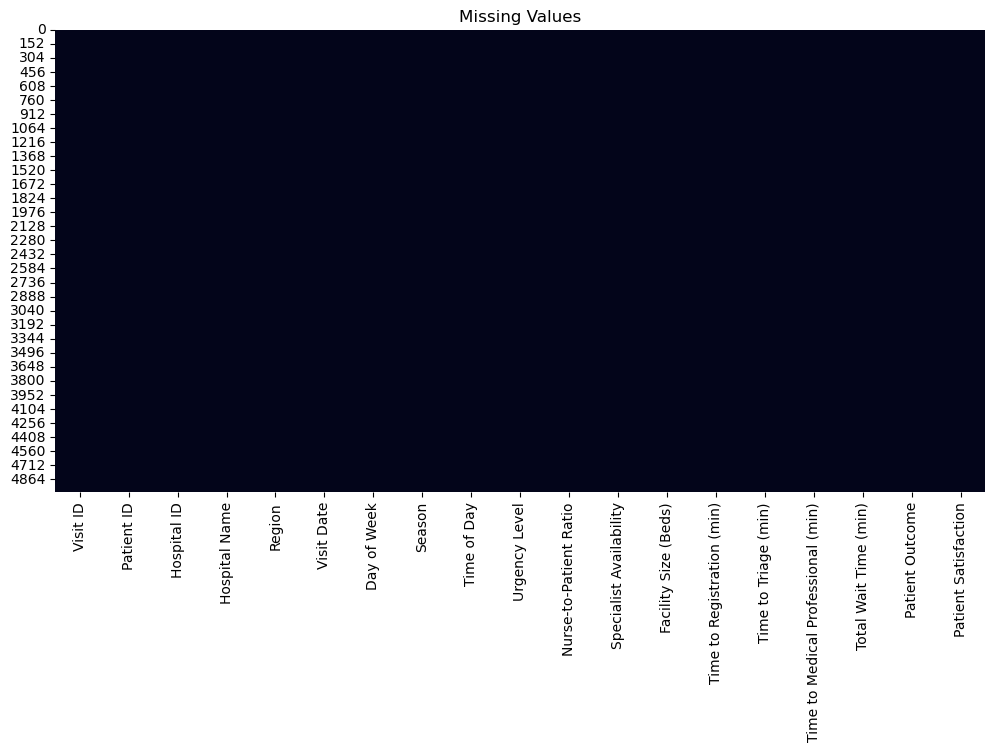

In [6]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values")
plt.show()

In [7]:
print(df.isnull().sum())
print(df.isnull().sum().sum())

Visit ID                              0
Patient ID                            0
Hospital ID                           0
Hospital Name                         0
Region                                0
Visit Date                            0
Day of Week                           0
Season                                0
Time of Day                           0
Urgency Level                         0
Nurse-to-Patient Ratio                0
Specialist Availability               0
Facility Size (Beds)                  0
Time to Registration (min)            0
Time to Triage (min)                  0
Time to Medical Professional (min)    0
Total Wait Time (min)                 0
Patient Outcome                       0
Patient Satisfaction                  0
dtype: int64
0


In [8]:
SimpleImputer(strategy="median")
SimpleImputer(strategy="most_frequent")

,missing_values,nan
,strategy,'most_frequent'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Visit ID                            5000 non-null   object
 1   Patient ID                          5000 non-null   object
 2   Hospital ID                         5000 non-null   object
 3   Hospital Name                       5000 non-null   object
 4   Region                              5000 non-null   object
 5   Visit Date                          5000 non-null   object
 6   Day of Week                         5000 non-null   object
 7   Season                              5000 non-null   object
 8   Time of Day                         5000 non-null   object
 9   Urgency Level                       5000 non-null   object
 10  Nurse-to-Patient Ratio              5000 non-null   int64 
 11  Specialist Availability             5000 non-null   int6

In [10]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(categorical_cols)

['Visit ID', 'Patient ID', 'Hospital ID', 'Hospital Name', 'Region', 'Visit Date', 'Day of Week', 'Season', 'Time of Day', 'Urgency Level', 'Patient Outcome']


In [11]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

print("Encoding Completed!")

Encoding Completed!


In [12]:
df.head()

,Visit ID,Patient ID,Hospital ID,Hospital Name,Region,Visit Date,Day of Week,Season,Time of Day,Urgency Level,Nurse-to-Patient Ratio,Specialist Availability,Facility Size (Beds),Time to Registration (min),Time to Triage (min),Time to Medical Professional (min),Total Wait Time (min),Patient Outcome,Patient Satisfaction
0,115,0,0,2,1,583,2,3,3,3,4,3,92,17,22,66,105,1,1
1,2931,1,2,0,0,4567,4,0,2,3,4,0,38,9,30,30,69,1,3
2,2766,2,2,0,0,3764,1,0,2,2,5,1,38,38,40,125,203,1,1
3,1163,3,1,1,1,811,5,3,2,1,4,5,94,8,16,64,88,1,2
4,180,4,0,2,1,926,6,1,0,2,4,8,74,26,29,63,118,1,1


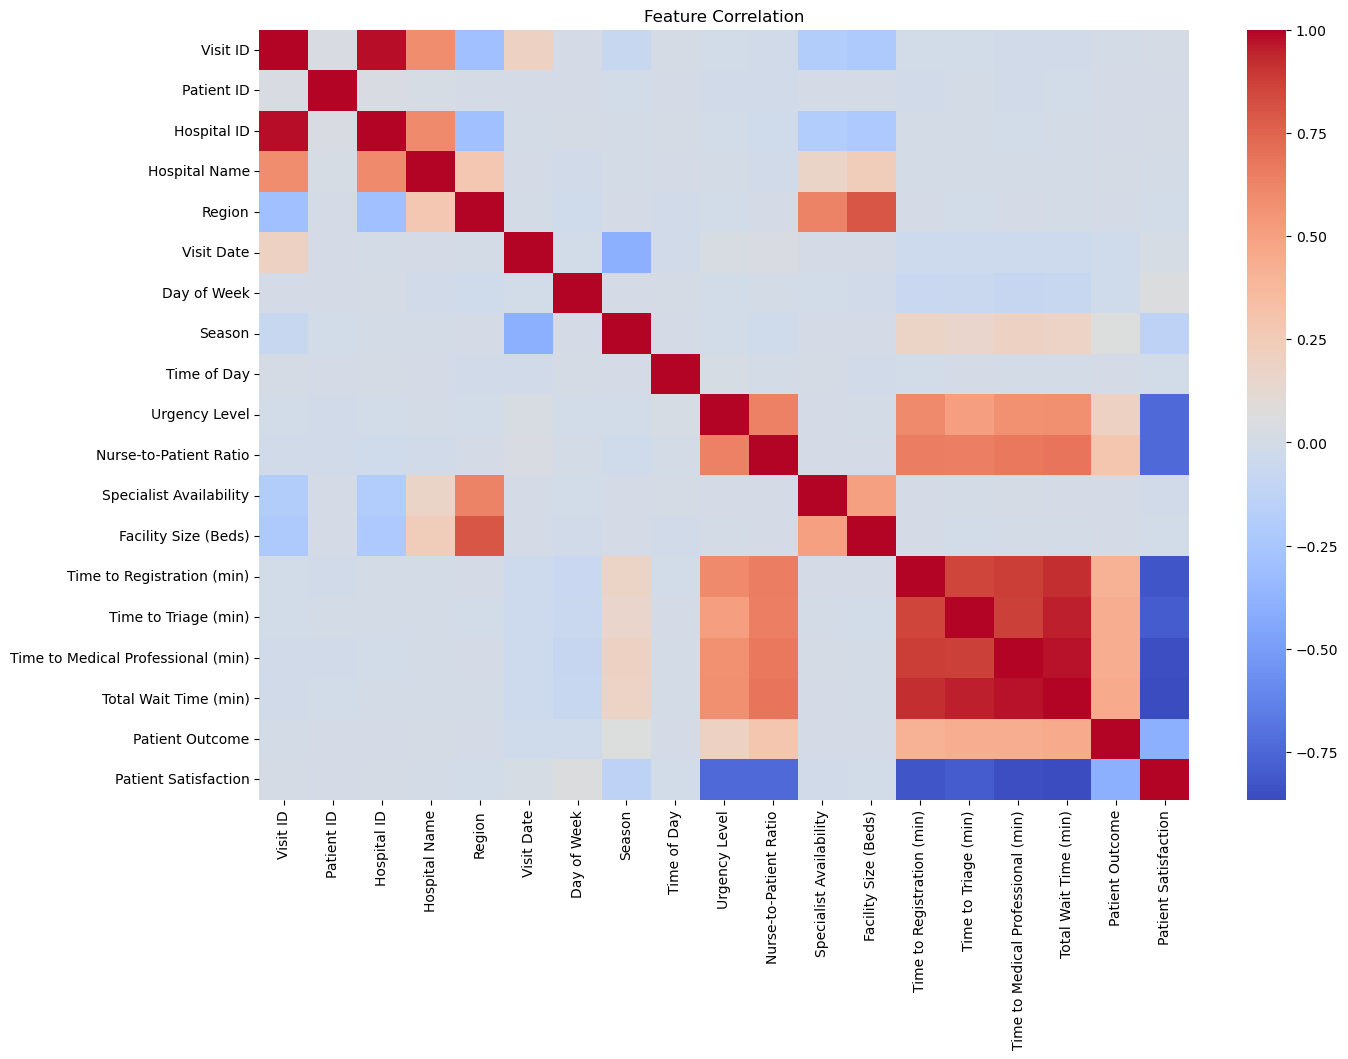

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,10))

sns.heatmap(df.corr(numeric_only=True),
            cmap='coolwarm',
            annot=False)

plt.title("Feature Correlation")

plt.show()

In [14]:
df["Urgency Level"].value_counts()

Urgency Level
3    1291
1    1245
0    1242
2    1222
Name: count, dtype: int64

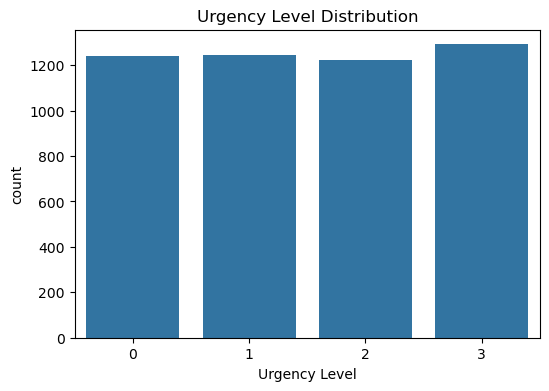

In [15]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Urgency Level")

plt.title("Urgency Level Distribution")

plt.show()

In [16]:
X = df.drop(columns=["Urgency Level"])

y = df["Urgency Level"]

In [17]:
print(X.shape)
print(y.shape)

(5000, 18)
(5000,)


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [19]:
print("Training Samples:", X_train.shape)
print("Testing Samples:", X_test.shape)

Training Samples: (4000, 18)
Testing Samples: (1000, 18)


In [20]:
processed = pd.concat([X, y], axis=1)

processed.to_csv("processed_dataset.csv", index=False)

print("Processed dataset saved successfully.")

Processed dataset saved successfully.


In [21]:
print(df.columns.tolist())


['Visit ID', 'Patient ID', 'Hospital ID', 'Hospital Name', 'Region', 'Visit Date', 'Day of Week', 'Season', 'Time of Day', 'Urgency Level', 'Nurse-to-Patient Ratio', 'Specialist Availability', 'Facility Size (Beds)', 'Time to Registration (min)', 'Time to Triage (min)', 'Time to Medical Professional (min)', 'Total Wait Time (min)', 'Patient Outcome', 'Patient Satisfaction']


In [24]:
!pip install xgboost

  Using cached xgboost-3.3.0-py3-none-win_amd64.whl.metadata (2.0 kB)
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   -----------------

ERROR: Could not install packages due to an OSError: [WinError 32] The process cannot access the file because it is being used by another process: 'C:\\Users\\hp\\AppData\\Local\\Temp\\pip-unpack-mmuwv4n0\\xgboost-3.3.0-py3-none-win_amd64.whl'
Consider using the `--user` option or check the permissions.



In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [30]:
lr = LogisticRegression(
    max_iter=5000,
    random_state=42
)

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

In [31]:
lr = LogisticRegression(
    max_iter=5000,
    random_state=42
)

In [32]:
max_iter=10000

In [33]:
# Scale for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression
lr.fit(X_train_scaled, y_train)



,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


In [34]:
X = df.drop(columns=[
    "Visit ID",
    "Patient ID",
    "Hospital ID",
    "Hospital Name",
    "Urgency Level"   # target column
])

y = df["Urgency Level"]

In [35]:
print(df.columns.tolist())

['Visit ID', 'Patient ID', 'Hospital ID', 'Hospital Name', 'Region', 'Visit Date', 'Day of Week', 'Season', 'Time of Day', 'Urgency Level', 'Nurse-to-Patient Ratio', 'Specialist Availability', 'Facility Size (Beds)', 'Time to Registration (min)', 'Time to Triage (min)', 'Time to Medical Professional (min)', 'Total Wait Time (min)', 'Patient Outcome', 'Patient Satisfaction']


In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(4000, 14)
(1000, 14)


In [37]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [38]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=5000,
    random_state=42
)

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

In [39]:
from sklearn.metrics import *

print("Accuracy:", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred, average="weighted"))
print("Recall:", recall_score(y_test, lr_pred, average="weighted"))
print("F1:", f1_score(y_test, lr_pred, average="weighted"))

Accuracy: 0.92
Precision: 0.920532611601176
Recall: 0.92
F1: 0.9200450657808699


In [40]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [41]:
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred, average="weighted"))
print("Recall:", recall_score(y_test, rf_pred, average="weighted"))
print("F1:", f1_score(y_test, rf_pred, average="weighted"))

Accuracy: 0.953
Precision: 0.953361642928974
Recall: 0.953
F1: 0.9529249325033793


In [42]:
!pip install xgboost

  Using cached xgboost-3.3.0-py3-none-win_amd64.whl.metadata (2.0 kB)
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.5/69.5 MB 2.2 MB/s eta 0:00:32
    --------------------------------------- 1.0/69.5 MB 2.1 MB/s eta 0:00:33
    --------------------------------------- 1.3/69.5 MB 1.8 MB/s eta 0:00:39
   - -------------------------------------- 1.8/69.5 MB 2.1 MB/s eta 0:00:33
   - -------------------------------------- 2.6/69.5 MB 2.5 MB/s eta 0:00:28
   -- ------------------------------------- 3.7/69.5 MB 2.9 MB/s eta 0:00:23
   -- ------------------------------------- 4.5/69.5 MB 3.1 MB/s eta 0:00:22
   --- ------------------------------------ 5.5/69.5 MB 3.3 MB/s eta 0:00:20
   --- ------------------------------------ 6.0/69.5 MB 3.2 MB/s eta 0:00:20
   ---- -------------------

In [43]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    objective='multi:softprob',
    num_class=len(y.unique()),
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='mlogloss'
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

In [44]:
print("Accuracy:", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred, average="weighted"))
print("Recall:", recall_score(y_test, xgb_pred, average="weighted"))
print("F1:", f1_score(y_test, xgb_pred, average="weighted"))

Accuracy: 0.976
Precision: 0.9759515083762679
Recall: 0.976
F1: 0.9759355811996604


In [45]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Logistic Regression","Random Forest","XGBoost"],
    "Accuracy":[
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ],
    "Precision":[
        precision_score(y_test, lr_pred, average='weighted'),
        precision_score(y_test, rf_pred, average='weighted'),
        precision_score(y_test, xgb_pred, average='weighted')
    ],
    "Recall":[
        recall_score(y_test, lr_pred, average='weighted'),
        recall_score(y_test, rf_pred, average='weighted'),
        recall_score(y_test, xgb_pred, average='weighted')
    ],
    "F1 Score":[
        f1_score(y_test, lr_pred, average='weighted'),
        f1_score(y_test, rf_pred, average='weighted'),
        f1_score(y_test, xgb_pred, average='weighted')
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.920,0.920533,0.920,0.920045
1,Random Forest,0.953,0.953362,0.953,0.952925
2,XGBoost,0.976,0.975952,0.976,0.975936


In [46]:
import joblib

joblib.dump(xgb, "best_model.pkl")

['best_model.pkl']

In [47]:
import joblib

joblib.dump(xgb, "best_model.pkl")

['best_model.pkl']

In [48]:
X = df.drop(columns=[
    "Visit ID",
    "Patient ID",
    "Hospital ID",
    "Hospital Name",
    "Visit Date",
    "Urgency Level"
])

In [49]:
print(X)

      Region  Day of Week  Season  Time of Day  Nurse-to-Patient Ratio  \
0          1            2       3            3                       4   
1          0            4       0            2                       4   
2          0            1       0            2                       5   
3          1            5       3            2                       4   
4          1            6       1            0                       4   
...      ...          ...     ...          ...                     ...   
4995       1            4       3            2                       2   
4996       0            3       2            2                       4   
4997       1            5       3            0                       3   
4998       1            6       2            0                       5   
4999       1            3       2            2                       4   

      Specialist Availability  Facility Size (Beds)  \
0                           3                    92   
1